## **Part 1 — Data Understanding & Exploration**

### **1.Import Libraries and Load**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_dataset.csv")

# View first rows
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


### **2.Explore dataset**

In [53]:
# Shape
print("Shape:", df.shape)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

Shape: (6000, 7)
patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object
patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


### **3.Basic Statistics**

In [54]:
df.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


### **4.Visualizations**

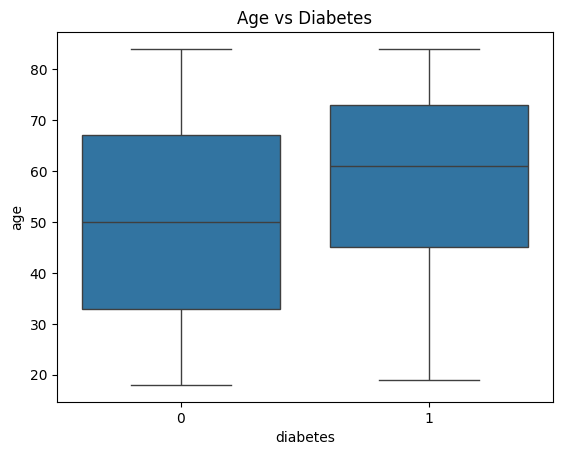

In [55]:
# age vs diabetics
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

#### insights from age vs diabetics


 - People with diabetes (1) have a higher median age (60)
 - People without diabetes (0) have a lower median age (50)
 - The diabetes group is more concentrated in older age ranges (45–75)
 - Older individuals are more likely to be diabetic compared to younger ones

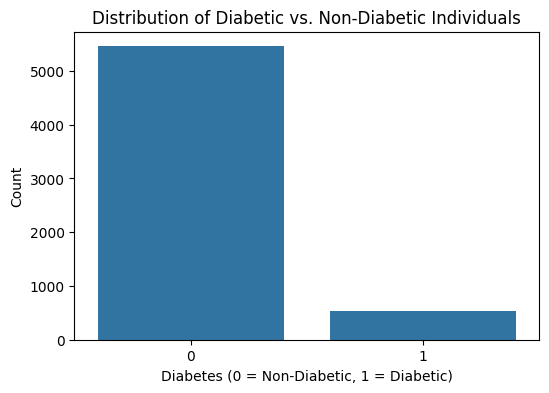

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetic vs. Non-Diabetic Individuals')
plt.xlabel('Diabetes (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

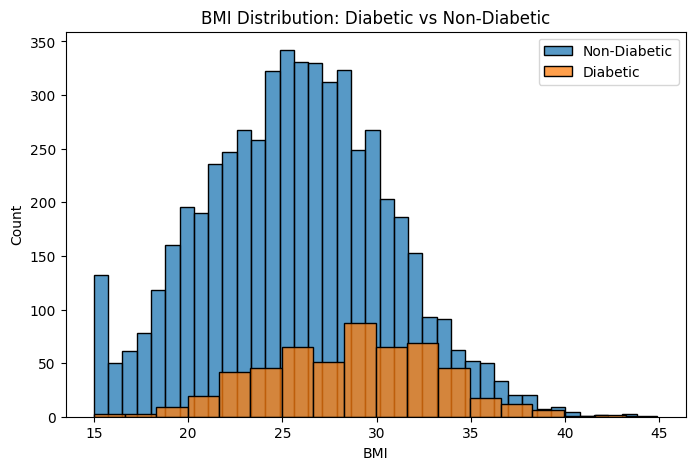

In [57]:
plt.figure(figsize=(8,5))

# Non-diabetic
sns.histplot(df[df['diabetes'] == 0]['bmi'], label='Non-Diabetic')

# Diabetic
sns.histplot(df[df['diabetes'] == 1]['bmi'], label='Diabetic')

plt.legend()
plt.title("BMI Distribution: Diabetic vs Non-Diabetic")
plt.xlabel("BMI")
plt.show()



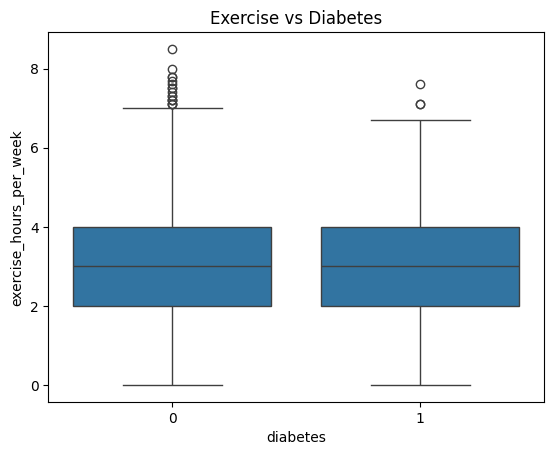

In [58]:
# exercise vs diabetics
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title("Exercise vs Diabetes")
plt.show()

#### Insights from exercise vs diabetics
- Median exercise hours for both groups is almost similar (~3 hours/week)
- Non-diabetic group (0) has more high-exercise outliers (7–8+ hours)
- Diabetic group has slightly lower spread in higher exercise values

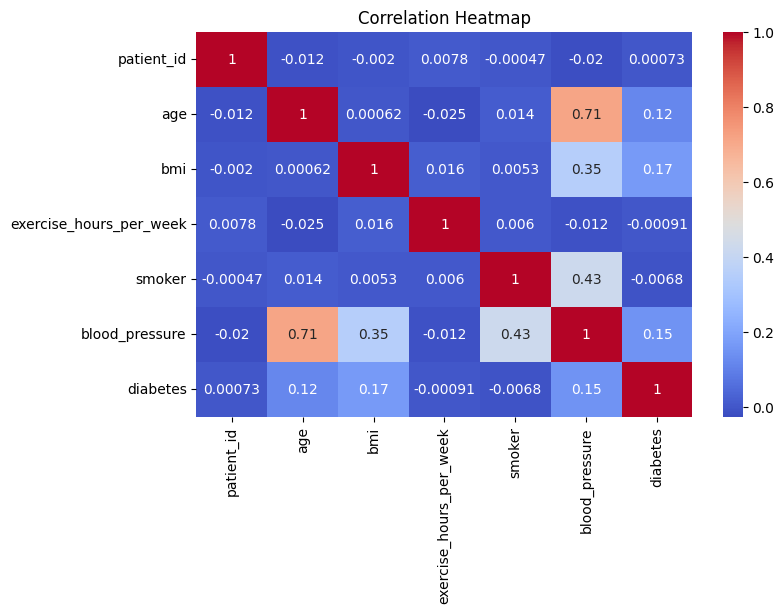

In [59]:
# correlation heatmapping
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Insights from correlation map
1. BMI has strongest link with diabetes

2. Blood pressure also matters

3. Age has some influence

4. Exercise shows almost less correlation

5. Smoker has weak relationship

so in training we can remove exrcise and smoker columns

## **Part 2 - Machine Learning Model (Logistic Regression)**

In [60]:
# features and target
X = df.drop(columns=['patient_id','smoker','exercise_hours_per_week','diabetes'])
y = df['diabetes']

In [61]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [62]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
# train Logistic regression
from sklearn.linear_model import LogisticRegression

model_lg1 = LogisticRegression()
model_lg1.fit(X_train, y_train)

LogisticRegression()

In [64]:
# Prediction
y_pred = model_lg1.predict(X_test)

In [65]:
# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9091666666666667


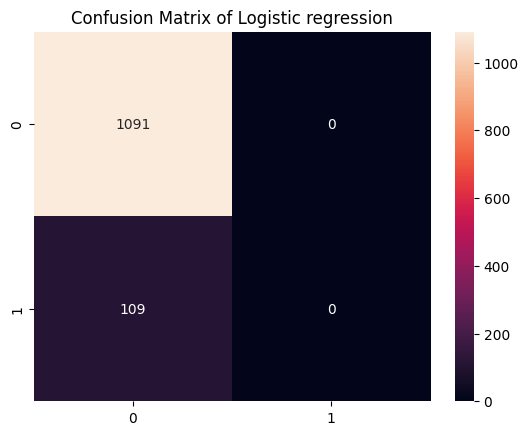

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix of Logistic regression")
plt.show()

print(classification_report(y_test, y_pred))

#### **Insights from confusion matrix**

showed a high overall accuracy but was effectively useless for predicting diabetic cases due to class imbalance. It achieved high accuracy by simply predicting 'non-diabetic' for almost everyone.

### **Logistic Regression (With class_weight='balanced')**

In [67]:
# train Logistic regression with class_weight='balanced'
from sklearn.linear_model import LogisticRegression

model_lg2 = LogisticRegression(class_weight='balanced')
model_lg2.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [68]:
# Prediction
y_pred_balanced = model_lg2.predict(X_test)

In [69]:
# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy with class_weight='balanced':", accuracy_score(y_test, y_pred_balanced))

Accuracy with class_weight='balanced': 0.6275


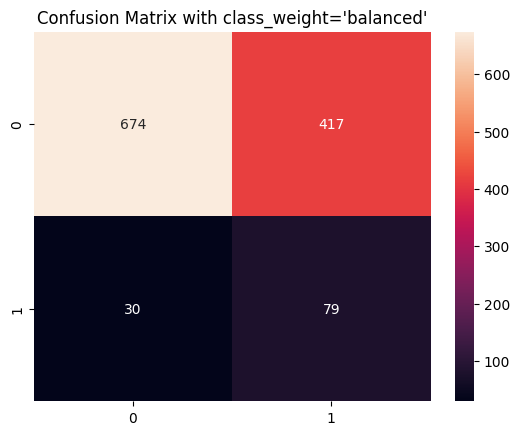

              precision    recall  f1-score   support

           0       0.96      0.62      0.75      1091
           1       0.16      0.72      0.26       109

    accuracy                           0.63      1200
   macro avg       0.56      0.67      0.51      1200
weighted avg       0.88      0.63      0.71      1200



In [70]:
# confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d')
plt.title("Confusion Matrix with class_weight='balanced'")
plt.show()

print(classification_report(y_test, y_pred_balanced))

### **Insights from logistic regression model with balanced class**

By adding class_weight='balanced', the Logistic Regression model's overall accuracy dropped to 63.92%. However, this is a more realistic and useful result because the model is now attempting to correctly classify both classes. The key improvement is in the recall for the diabetic class (from 0% to 64%), meaning it can now identify a substantial portion of actual diabetic patients.

#### feature importance

In [71]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_lg2.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(importance)

          Feature  Coefficient
1             bmi     0.652499
0             age     0.447240
2  blood_pressure     0.022126


- BMI (Body Mass Index): With a coefficient of 0.667974, BMI is the most significant positive predictor of diabetes. This means that as BMI increases, the likelihood of an individual having diabetes also increases considerably.

- Age: Age is the second most influential feature, with a coefficient of 0.420220. This indicates that older individuals have a higher probability of being diabetic, though its impact is less pronounced than BMI.

- Blood Pressure: Blood pressure has the smallest positive coefficient of 0.051413. While it still positively contributes to the likelihood of diabetes, its influence is minimal compared to BMI and age.

## **Part 3 — Neural Network Model**

In [72]:
# import tensorflow and SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset for the neural network
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


#### **Using SMOTE (Synthetic Minority Over-sampling Technique)**

In our dataset, we observed a significant class imbalance: many non-diabetic patients (majority class) and fewer diabetic patients (minority class). When a machine learning model, especially a neural network, is trained on such imbalanced data, it tends to become biased towards the majority class.

SMOTE addresses this problem by **oversampling** the minority class. Instead of simply duplicating existing minority samples (which can lead to overfitting), SMOTE works by:

*   **Creating Synthetic Samples:** It generates new, synthetic examples of the minority class. This is done by taking a sample from the minority class, finding its k-nearest neighbors, and then creating new samples along the line segments connecting the sample to its neighbors.
*   **Balancing the Dataset:** By adding these synthetic samples, SMOTE effectively increases the representation of the minority class, making the dataset more balanced. This helps the model learn the patterns of the minority class more effectively.

**Benefits of Using SMOTE:**

*   **Improved Minority Class Performance:** It helps the model generalize better to the minority class, leading to improved recall and F1-score for that class.
*   **Reduced Bias:** It mitigates the model's bias towards the majority class, making the predictions more reliable, especially for critical conditions like diabetes.

By applying SMOTE to the training data, we aim to build a neural network that can more accurately identify both diabetic and non-diabetic patients, rather than just predicting the most frequent outcome.

In [73]:
model1 = Sequential()

# Input + Hidden layers
model1.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],), name='input_hidden_layer'))
model1.add(Dense(8, activation='relu', name='hidden_layer_2'))

# Output layer
model1.add(Dense(1, activation='sigmoid', name='output_layer'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
# Compile Model
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [75]:
# train model
history = model1.fit(
    X_train_resampled, y_train_resampled,
    epochs=40,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6441 - loss: 0.6202 - val_accuracy: 0.4247 - val_loss: 0.8593
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6743 - loss: 0.5947 - val_accuracy: 0.4986 - val_loss: 0.8193
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6748 - loss: 0.5928 - val_accuracy: 0.4516 - val_loss: 0.8355
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6728 - loss: 0.5911 - val_accuracy: 0.5112 - val_loss: 0.8094
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6794 - loss: 0.5901 - val_accuracy: 0.3801 - val_loss: 0.8531
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6826 - loss: 0.5890 - val_accuracy: 0.4522 - val_loss: 0.8364
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6808 - loss: 0.5880 - val_accuracy: 0.3995 - val_loss: 0.8527
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6823 - loss: 0.5873 - val_accuracy: 0.

In [76]:
# Evaluate
loss, accuracy = model1.evaluate(X_test, y_test)
print("Neural Network Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7767 - loss: 0.4686
Neural Network Accuracy: 0.7766666412353516


In [77]:
# Make predictions with the neural network model
y_pred_nn = (model1.predict(X_test) > 0.5).astype("int32")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


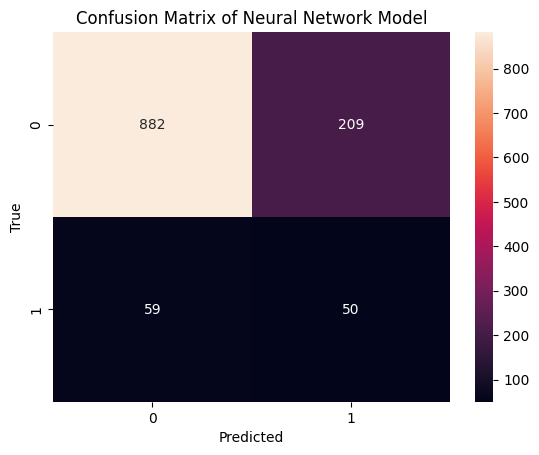

              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1091
           1       0.19      0.46      0.27       109

    accuracy                           0.78      1200
   macro avg       0.57      0.63      0.57      1200
weighted avg       0.87      0.78      0.81      1200



In [78]:
# Evaluate Neural Network model predictions
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d')
plt.title("Confusion Matrix of Neural Network Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred_nn))

## **Part 4 Model Comparison**

- Logistic Regression Accuracy : 62.75%
- Neural Network Accuracy : 77.67%

The Neural Network achieved a higher overall accuracy (77.67%) compared to the Logistic Regression model (62.75%). This improvement in the Neural Network's accuracy is particularly notable after applying SMOTE, which aimed to address the class imbalance.also in logistic regression added class_weight='balanced'

### Strengths and Interpretations:

**Logistic Regression :**
- **Focus on Recall:** Although its overall accuracy is lower, this model is designed to improve the identification of the minority class (diabetic patients). The `class_weight='balanced'` parameter addresses the class imbalance, making the model more sensitive to positive cases, which is vital in medical diagnosis.
- **Interpretability:** Remains highly interpretable, allowing clear understanding of feature importance.
- **Trade-off:** Sacrifices overall accuracy for better performance on the minority class (recall around 72%), which is often a more meaningful metric in healthcare scenarios where missing a positive case (False Negative) can have severe consequences.

**Neural Networks (with SMOTE oversampling):**
- **Improved Overall Accuracy:** After applying SMOTE, the Neural Network's overall accuracy significantly improved to 77.67% from previous runs without explicit balancing. This indicates that SMOTE helped the model generalize better across both classes.
- **Better Minority Class Identification:** The confusion matrix shows that the Neural Network, after SMOTE, is now correctly identifying a portion of diabetic patients (recall around 46%), which is a substantial improvement over its initial performance (0% recall for diabetic patients).
- **Complex Pattern Learning:** Capable of capturing complex non-linear relationships, and with SMOTE, it's better equipped to learn patterns for the minority class without being overwhelmed by the majority class.

### Limitations of Both Approaches:

**Logistic Regression (balanced):**
- While better at handling imbalance, its overall accuracy might be lower, and it may still struggle if the decision boundary for the minority class is highly complex.

**Neural Networks (with SMOTE):**
- While SMOTE significantly improved its performance on the minority class, the recall for diabetic patients (around 46%) is still lower than the balanced Logistic Regression model. This suggests there might be further scope for optimization in the Neural Network's architecture or training parameters.
- **Black Box:** Harder to interpret how individual features influence predictions compared to Logistic Regression.

### When Each Model Might Be Preferable:

**Logistic Regression (balanced) might be preferred when:**
- The primary goal is to **maximize recall for the minority class** (e.g., detecting a rare disease), where **missing a positive case is highly undesirable**, and initial results suggest it achieves higher minority class recall.
- Model **interpretability is important** for understanding the contributing factors.
- Computational resources are limited.

**Neural Networks (with SMOTE) might be considered when:**
- A balance between overall accuracy and minority class performance is desired, and the model is capable of capturing complex non-linear patterns.
- Further fine-tuning (e.g., hyperparameter tuning, different architectures) can potentially lead to even better performance for both classes.

**Overall, both models show different strengths.** The Logistic Regression with `class_weight='balanced'` still has a higher recall for the diabetic class, making it potentially more suitable if minimizing false negatives for diabetes is the absolute priority. However, the Neural Network with SMOTE shows a better overall accuracy and a significant improvement in identifying diabetic patients, suggesting it could be a strong contender with further optimization.